In [2]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

df_da = df[df['job_title_short'] == 'Data Analyst'].copy()

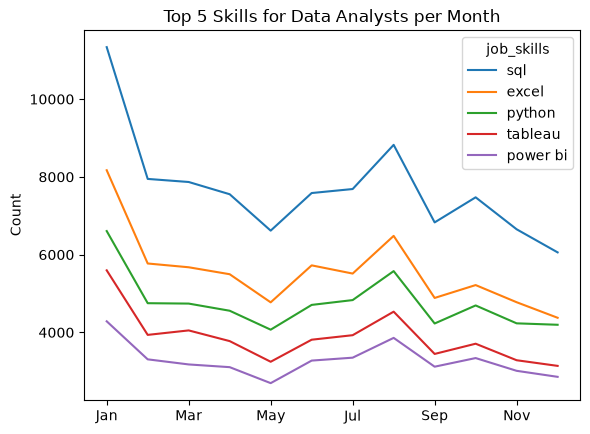

In [3]:
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()
# create a new column for month number
df_DA['job_posted_month_no'] = df_DA['job_posted_date'].dt.month

# Explode the job_skills column and pivot
df_DA_explode= df_DA.explode('job_skills')
df_DA_pivot = df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

# sort the skills by count
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_pivot = df_DA_pivot.drop('Total')

# Use month names for plotting
df_DA_pivot = df_DA_pivot.reset_index()
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

# Get the top 5 skills
df_DA_pivot.iloc[:, :5].plot(kind='line')

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

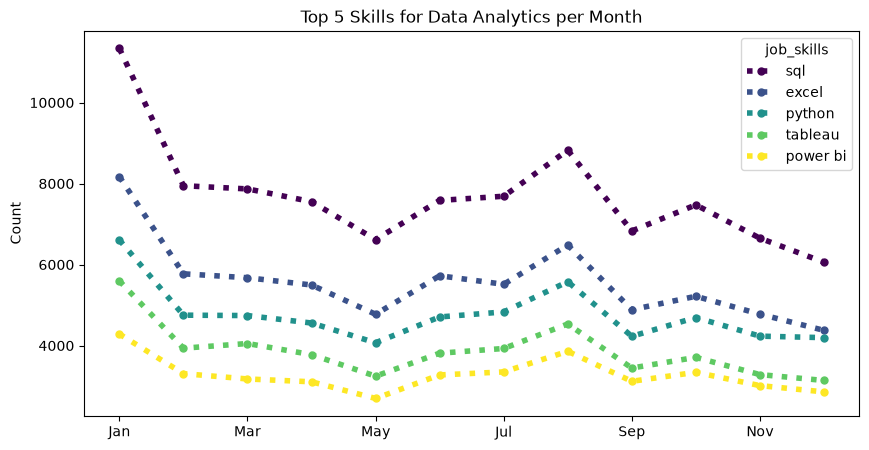

In [4]:
df_DA_pivot.iloc[:, :5].plot(
    kind='line',
    linewidth=4,
    linestyle=':',
    colormap='viridis',
    marker='o',
    markersize=5,
    figsize=(10, 5)
)
  
plt.title('Top 5 Skills for Data Analytics per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()


In [5]:

df_exploded = df_DA.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    median_salary=('salary_year_avg', 'median'),
    skill_count=('job_skills', 'count')
)

skill_count = 20
skill_stats = skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)

skill_stats


,median_salary,skill_count
job_skills,,
sql,92500.000000,92428
excel,84479.000000,66860
python,98500.000000,57190
tableau,95000.000000,46455
power bi,90000.000000,39380
r,92527.500000,29996
sas,90000.000000,27998
powerpoint,85000.000000,13822
word,80000.000000,13562


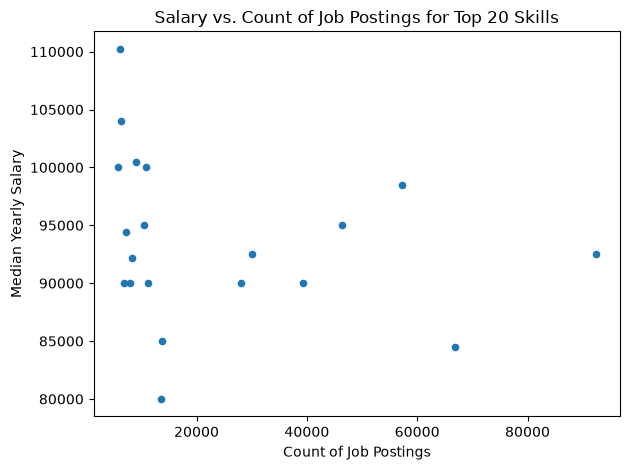

In [6]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

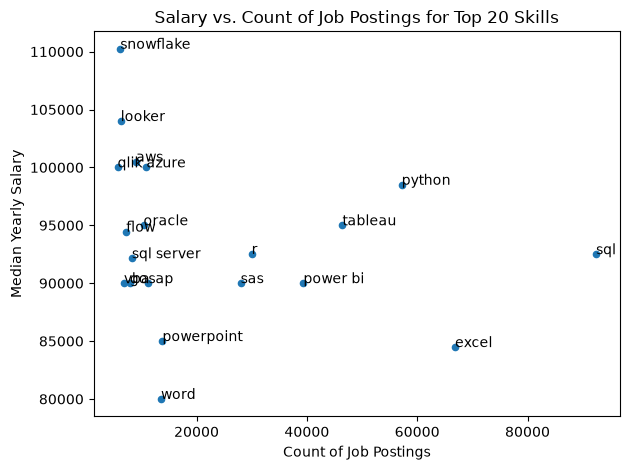

In [7]:
skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt)

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()

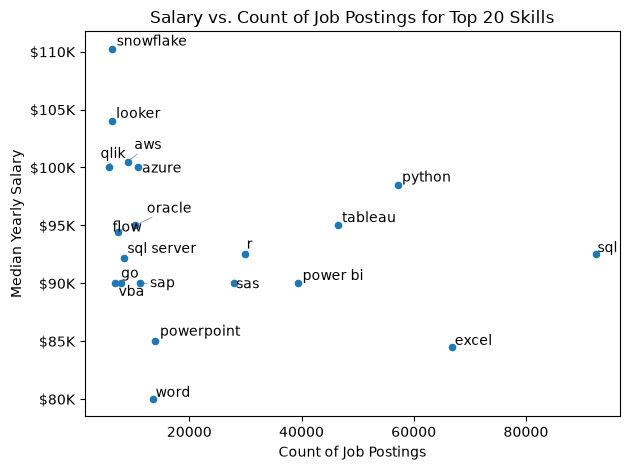

In [15]:
from adjustText import adjust_text

skill_stats.plot(kind='scatter', x='skill_count', y='median_salary')

texts = []

for i, txt in enumerate(skill_stats.index):
    texts.append(plt.text(skill_stats['skill_count'].iloc[i], skill_stats['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

ax = plt.gca()  

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')

plt.tight_layout()
plt.show()

# 1;01;12

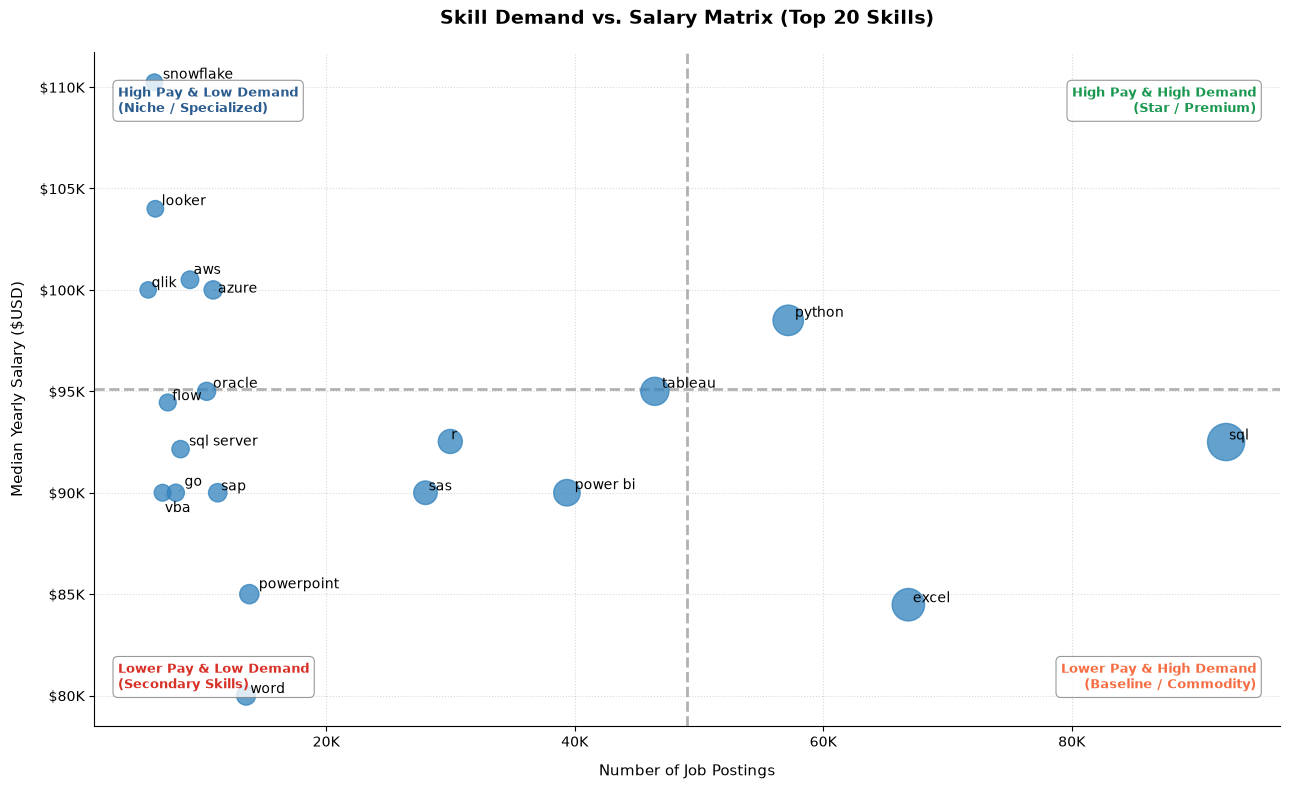

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from adjustText import adjust_text

# 1. Figure size configuration
fig, ax = plt.subplots(figsize=(13, 8))

# 2. Scatter plot with dynamic point size
scatter = ax.scatter(
    skill_stats['skill_count'], 
    skill_stats['median_salary'],
    s = skill_stats['skill_count'] / 150 + 100,
    color='#3182bd', 
    alpha=0.75, 
    edgecolors='black',
    linewidth=1,
    zorder=3
)

center_x = (skill_stats['skill_count'].min() + skill_stats['skill_count'].max()) / 2
center_y = (skill_stats['median_salary'].min() + skill_stats['median_salary'].max()) / 2

ax.axvline(center_x, color='gray', linestyle='--', alpha=0.6, lw=2.0, zorder=1)
ax.axhline(center_y, color='gray', linestyle='--', alpha=0.6, lw=2.0, zorder=1)

bbox_props = dict(boxstyle="round,pad=0.4", fc="white", ec="gray", alpha=0.8, lw=0.8)

# top-left
ax.text(0.02, 0.95, 'High Pay & Low Demand\n(Niche / Specialized)', 
        transform=ax.transAxes, fontsize=9, fontweight='bold', color='#2b5c8f', 
        va='top', ha='left', bbox=bbox_props)

# top-right
ax.text(0.98, 0.95, 'High Pay & High Demand\n(Star / Premium)', 
        transform=ax.transAxes, fontsize=9, fontweight='bold', color='#1a9850', 
        va='top', ha='right', bbox=bbox_props)

# bottom-left
ax.text(0.02, 0.05, 'Lower Pay & Low Demand\n(Secondary Skills)', 
        transform=ax.transAxes, fontsize=9, fontweight='bold', color='#d73027', 
        va='bottom', ha='left', bbox=bbox_props)

# bottom-right
ax.text(0.98, 0.05, 'Lower Pay & High Demand\n(Baseline / Commodity)', 
        transform=ax.transAxes, fontsize=9, fontweight='bold', color='#f46d43', 
        va='bottom', ha='right', bbox=bbox_props)

texts = []
for i, txt in enumerate(skill_stats.index):
    texts.append(ax.text(skill_stats['skill_count'].iloc[i], 
                         skill_stats['median_salary'].iloc[i], 
                         txt, fontsize=10, fontweight='medium'))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.6, alpha=0.7))

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x/1000)}K'))

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, linestyle=':', alpha=0.3, color='gray')

plt.title('Skill Demand vs. Salary Matrix (Top 20 Skills)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Number of Job Postings', fontsize=11, labelpad=10)
plt.ylabel('Median Yearly Salary ($USD)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()
